In [1]:
import pandas as pd
import seaborn as sns
import label
from metadata import get_json
from ripser import Rips
from persim import wasserstein
from sklearn.manifold import MDS, TSNE
from gudhi.representations import PersistenceScaleSpaceKernel
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
sns.set_style("darkgrid")
muscles = get_json("muscles")

In [2]:
def takens_indices(tau, d, n_samples):
    def _takens_indices(t):
        return [t + n * tau for n in range(d + 1)]
    return list(filter(lambda x: x[-1] < n_samples, map(_takens_indices, range(n_samples))))

def trial_to_takens_embeddings(trial, tau, d, sample_rate=20):
    data = pd.read_csv(f"data/{trial}.csv")[muscles]
    embedding = data.values[takens_indices(tau=tau, d=d, n_samples=data.shape[0])]
    embedding = embedding.reshape(embedding.shape[0], -1)
    return (trial, embedding[::sample_rate])

trials = list(label.LabelDataset(label.label_filter(None, None, None)))

cs_labels = [trial.subject == "21" or trial.subject == "22" for trial in trials]
cond_labels = [trial.condition for trial in trials]
acti_labels = [trial.activity for trial in trials]

In [3]:
%%capture

trials_takens_embeddings = dict([trial_to_takens_embeddings(trial, 250, 50, sample_rate=100) for trial in trials])

trials_ripsers = dict([(trial, Rips().fit_transform(trials_takens_embeddings[trial])) for trial in trials])

In [4]:
import csv

In [5]:
for t, h in list(trials_ripsers.items()):
    with open(f"ripsers/trials/{t}.csv", "w", newline="\n") as file:
        writer = csv.writer(file)
        writer.writerow(["s", "c", "a", "h", "0", "1"])
        for i in range(len(h)):
            for j in range(len(h[i])):
                writer.writerow([t.subject, t.condition, t.activity, i, h[i][j][0], h[i][j][1]])

In [6]:
%%capture

stacked_rips_h0 = [rips[0] for rips in trials_ripsers.values()]

pairwise_distances = np.zeros((len(stacked_rips_h0), len(stacked_rips_h0)))

precomputed_indices = []
for i in range(len(stacked_rips_h0)):
    for j in range(i, len(stacked_rips_h0)):
        if i == j:
            continue
        else:
            precomputed_indices.append((i, j))

for i, j in tqdm(precomputed_indices):
    d = wasserstein(stacked_rips_h0[i], stacked_rips_h0[j])
    pairwise_distances[i, j] = d
pairwise_distances = pairwise_distances + pairwise_distances.T

tsne = TSNE(n_components=2, metric="precomputed", init="random").fit_transform(pairwise_distances)

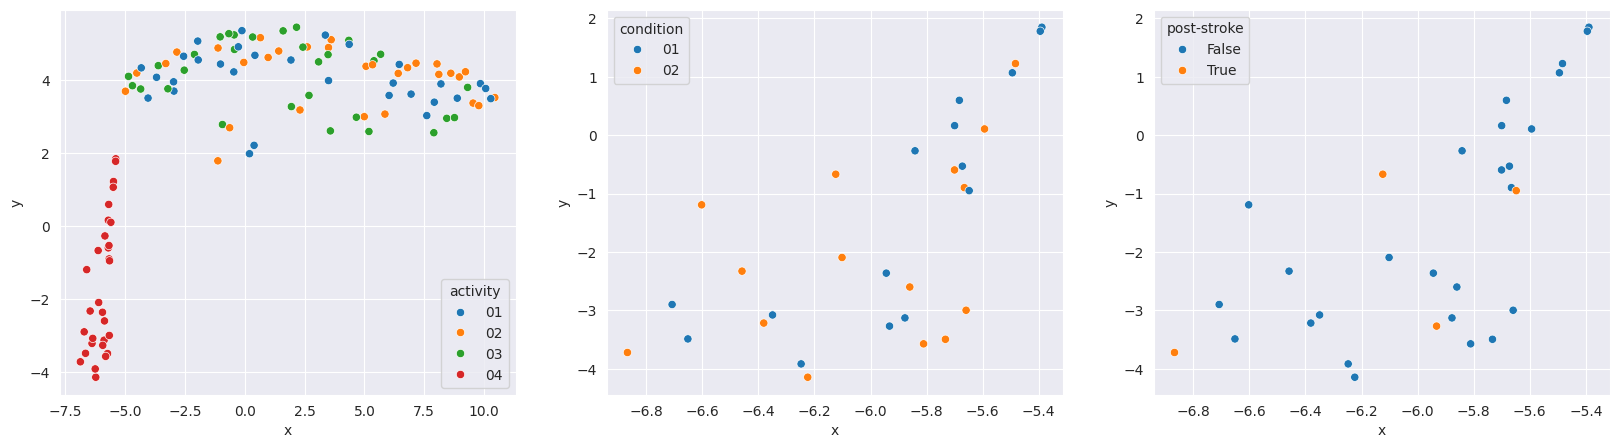

In [7]:
pd.DataFrame(pairwise_distances).to_csv(f"./pairwise-distances/trials/pairwise-h0.csv", index=False)

tsne_df = pd.DataFrame(tsne, columns=["x", "y"])
tsne_df["post-stroke"] = cs_labels
tsne_df["condition"] = cond_labels
tsne_df["activity"] = acti_labels

tsne_df.to_csv("./tsne-0-trials.csv")

fig, axs = plt.subplots(1, 3, figsize=(20, 5))
sns.scatterplot(tsne_df, x="x", y="y", hue="activity", ax=axs[0]);
sns.scatterplot(tsne_df[tsne_df["activity"] == "04"], x="x", y="y", hue="condition", ax=axs[1]);
sns.scatterplot(tsne_df[tsne_df["activity"] == "04"], x="x", y="y", hue="post-stroke", ax=axs[2]);
plt.savefig(f"./figures/trials/tsne-h0.pdf")

In [8]:
stacked_rips_h1 = [rips[1] for rips in trials_ripsers.values()]

pairwise_distances_h1 = np.zeros((len(stacked_rips_h1), len(stacked_rips_h1)))

precomputed_indices = []
for i in range(len(stacked_rips_h1)):
    for j in range(i, len(stacked_rips_h1)):
        if i == j:
            continue
        else:
            precomputed_indices.append((i, j))

for i, j in tqdm(precomputed_indices):
    d = wasserstein(stacked_rips_h1[i], stacked_rips_h1[j])
    pairwise_distances_h1[i, j] = d
pairwise_distances_h1 = pairwise_distances_h1 + pairwise_distances_h1.T

tsne = TSNE(n_components=2, metric="precomputed", init="random").fit_transform(pairwise_distances_h1)

100%|██████████| 7140/7140 [00:28<00:00, 249.46it/s]


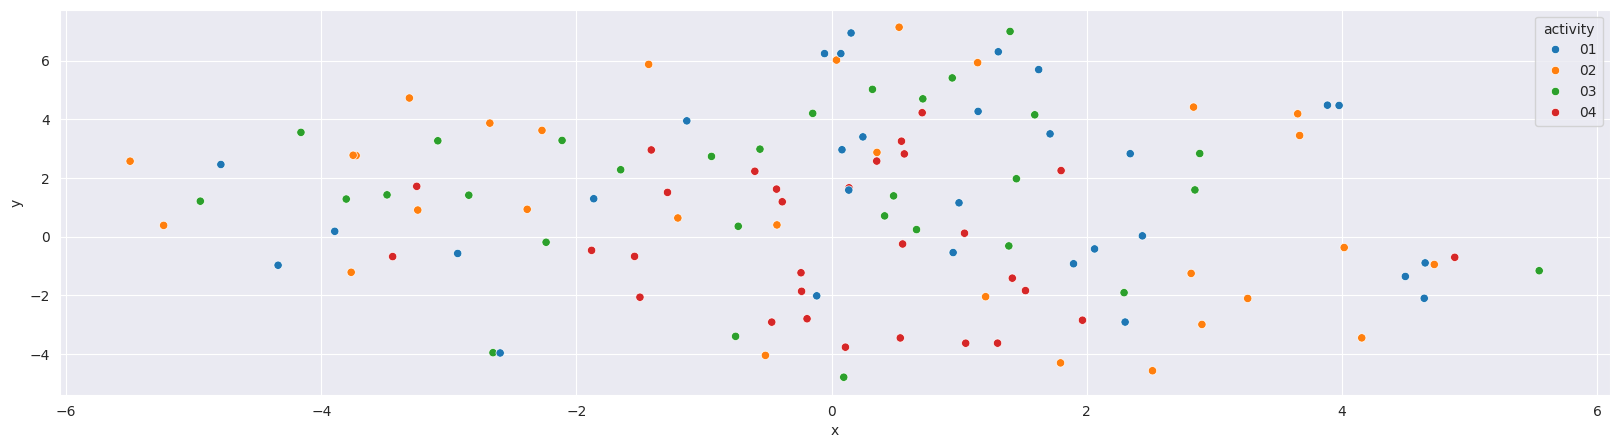

In [9]:
pd.DataFrame(pairwise_distances).to_csv(f"./pairwise-distances/trials/pairwise-h1.csv", index=False)

tsne_df = pd.DataFrame(tsne, columns=["x", "y"])
tsne_df["post-stroke"] = cs_labels
tsne_df["condition"] = cond_labels
tsne_df["activity"] = acti_labels

tsne_df.to_csv("./tsne-1-trials.csv")

fig, axs = plt.subplots(1, 1, figsize=(20, 5))
sns.scatterplot(tsne_df, x="x", y="y", hue="activity", ax=axs);
plt.savefig(f"./figures/trials/tsne-h1.pdf")